# Перцептрон (MLPClassifier)

**Цель работы:** познакомиться с перцептроном как моделью обучения с учителем в библиотеке sklearn.

**Содержание работы:**
1. Генерация многоклассовых данных и визуализация.
2. Обучение перцептрона без нормализации — анализ проблемы.
3. Нормализация данных (StandardScaler) и повторное обучение.
4. Увеличение числа итераций и глубины сети для улучшения точности.

## 1. Импорт библиотек и генерация данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

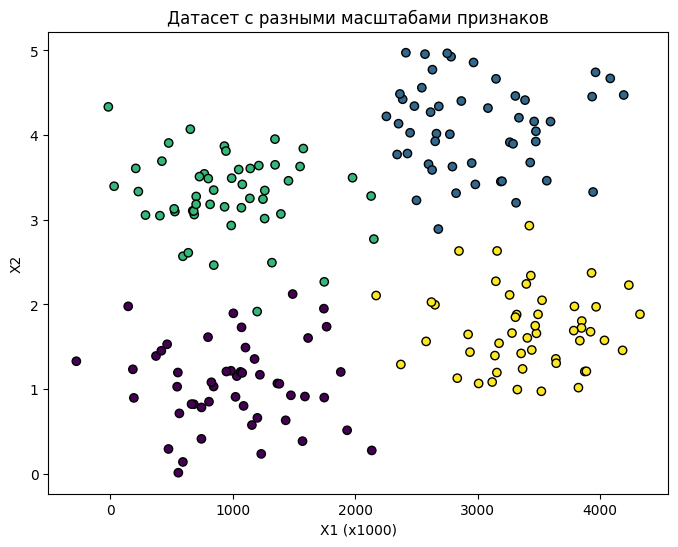

In [2]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, centers=blob_centers, cluster_std=0.5, random_state=0)
X[:, 0] *= 1000  # Разные масштабы признаков

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (x1000)')
plt.ylabel('X2')
plt.title('Датасет с разными масштабами признаков')
plt.show()

## 2. Обучение без нормализации

In [3]:
clf = MLPClassifier(hidden_layer_sizes=(6,), random_state=1, max_iter=200)
clf.fit(X, y)

print('Веса между входным и скрытым слоем:')
print(clf.coefs_[0].shape)
print('\nВеса между скрытым и выходным слоем:')
print(clf.coefs_[1].shape)
print(f'\nВеса смещения скрытого слоя: {clf.intercepts_[0].shape}')
print(f'Веса смещения выходного слоя: {clf.intercepts_[1].shape}')
print(f'\nКоличество нейронов на входе: 2')
print(f'Количество нейронов на скрытом слое: 6')
print(f'Количество нейронов на выходе: 4 (по числу классов)')

Веса между входным и скрытым слоем:
(2, 6)

Веса между скрытым и выходным слоем:
(6, 4)

Веса смещения скрытого слоя: (6,)
Веса смещения выходного слоя: (4,)

Количество нейронов на входе: 2
Количество нейронов на скрытом слое: 6
Количество нейронов на выходе: 4 (по числу классов)


In [4]:
y_pred_bad = clf.predict(X)
print('Матрица классификации (без нормализации):')
print(confusion_matrix(y, y_pred_bad))
print(f'Accuracy: {accuracy_score(y, y_pred_bad):.4f}')

Матрица классификации (без нормализации):
[[ 0  0  0 50]
 [ 0  0  0 50]
 [ 0  0  0 50]
 [ 0  0  0 50]]
Accuracy: 0.2500


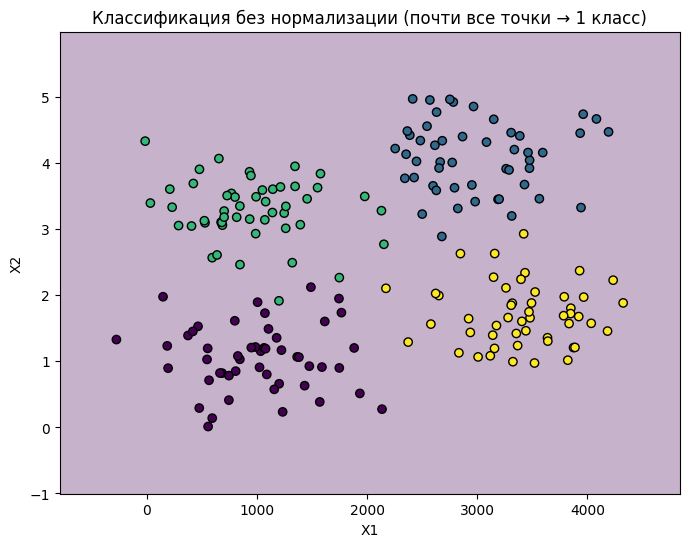

In [5]:
X0 = np.linspace(X[:, 0].min() - 500, X[:, 0].max() + 500, 200)
X1 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)
y_predict_bad = clf.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_grid, X1_grid, y_predict_bad, alpha=0.3, shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Классификация без нормализации (почти все точки → 1 класс)')
plt.show()

Без нормализации модель относит почти все точки к одному классу. Причина: признаки имеют сильно разные масштабы (X1 ~1000, X2 ~1), и градиентный спуск сходится очень медленно по малому признаку.

## 3. Нормализация данных (StandardScaler)

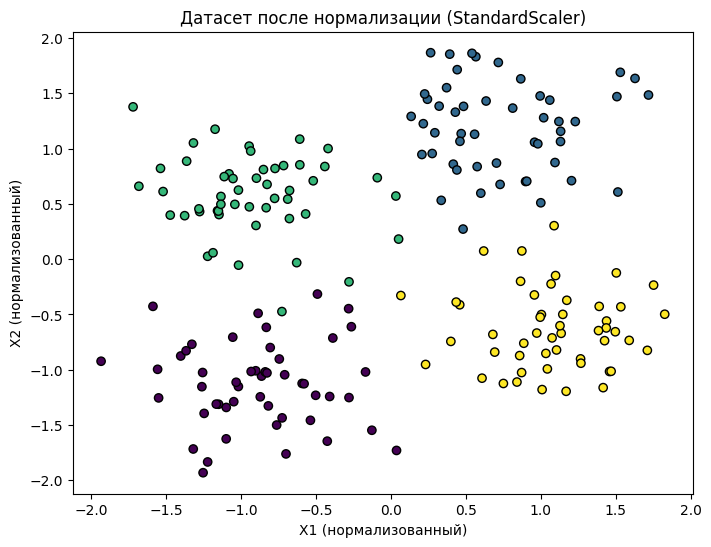

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Датасет после нормализации (StandardScaler)')
plt.show()

In [7]:
clf_scaled = MLPClassifier(hidden_layer_sizes=(6,), random_state=1, max_iter=200)
clf_scaled.fit(X_scaled, y)

y_pred_scaled = clf_scaled.predict(X_scaled)
print('Матрица классификации (с нормализацией):')
print(confusion_matrix(y, y_pred_scaled))
print(f'Accuracy: {accuracy_score(y, y_pred_scaled):.4f}')

Матрица классификации (с нормализацией):
[[22  0 11 17]
 [ 0 38  0 12]
 [ 0  3 45  2]
 [ 0  5  0 45]]
Accuracy: 0.7500


c:\Users\w1nore\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


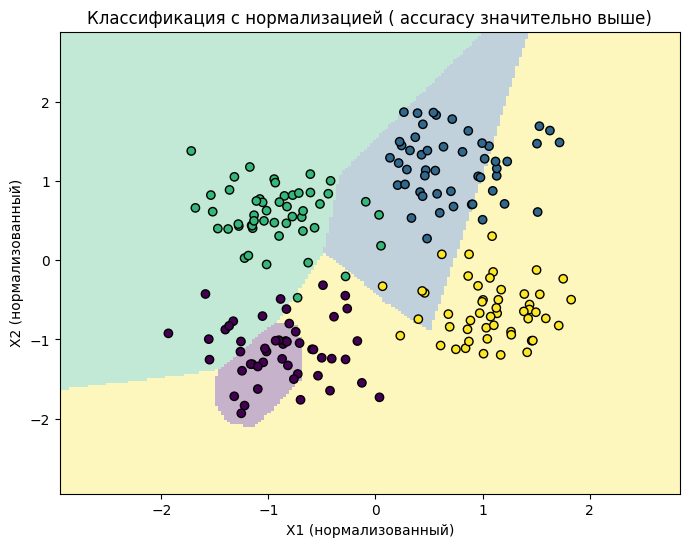

In [8]:
X0_s = np.linspace(X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1, 200)
X1_s = np.linspace(X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1, 200)
X0_sg, X1_sg = np.meshgrid(X0_s, X1_s)
y_predict_s = clf_scaled.predict(np.c_[X0_sg.ravel(), X1_sg.ravel()]).reshape(X0_sg.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_sg, X1_sg, y_predict_s, alpha=0.3, shading='auto')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Классификация с нормализацией ( accuracy значительно выше)')
plt.show()

После нормализации accuracy значительно вырос — границы классов стали ближе к реальным кластерам.

## 4. Увеличение числа итераций

In [9]:
clf_more_iter = MLPClassifier(hidden_layer_sizes=(6,), random_state=1, max_iter=10000)
clf_more_iter.fit(X_scaled, y)

y_pred_iter = clf_more_iter.predict(X_scaled)
print('Матрица классификации (max_iter=10000):')
print(confusion_matrix(y, y_pred_iter))
print(f'Accuracy: {accuracy_score(y, y_pred_iter):.4f}')

Матрица классификации (max_iter=10000):
[[50  0  0  0]
 [ 0 49  0  1]
 [ 2  3 45  0]
 [ 0  1  0 49]]
Accuracy: 0.9650


## 5. Глубокая нейросеть (3 скрытых слоя)

In [10]:
clf_deep = MLPClassifier(hidden_layer_sizes=(6, 6, 6), random_state=1, max_iter=10000)
clf_deep.fit(X_scaled, y)

y_pred_deep = clf_deep.predict(X_scaled)
print('Матрица классификации (3 слоя по 6 нейронов):')
print(confusion_matrix(y, y_pred_deep))
print(f'Accuracy: {accuracy_score(y, y_pred_deep):.4f}')

Матрица классификации (3 слоя по 6 нейронов):
[[49  0  1  0]
 [ 0 49  0  1]
 [ 1  0 49  0]
 [ 0  0  0 50]]
Accuracy: 0.9850


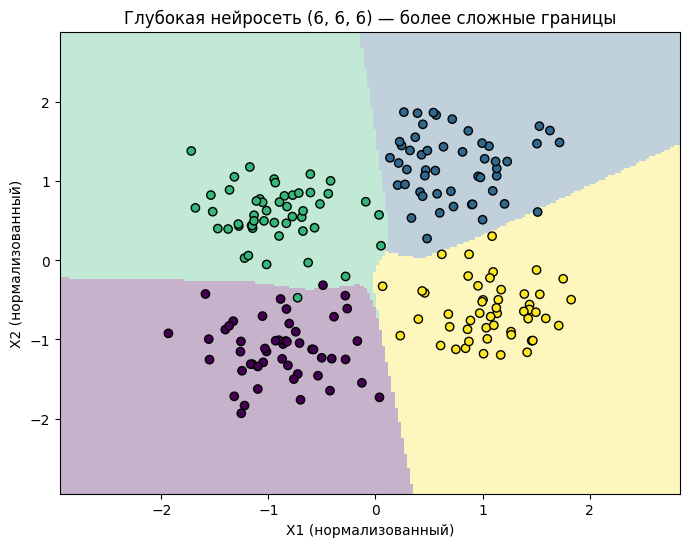

In [11]:
y_predict_deep = clf_deep.predict(np.c_[X0_sg.ravel(), X1_sg.ravel()]).reshape(X0_sg.shape)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X0_sg, X1_sg, y_predict_deep, alpha=0.3, shading='auto')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, edgecolors='black', linewidth=1)
plt.xlabel('X1 (нормализованный)')
plt.ylabel('X2 (нормализованный)')
plt.title('Глубокая нейросеть (6, 6, 6) — более сложные границы')
plt.show()

## Выводы

1. **Проблема масштабов**: без нормализации перцептрон не сходится — почти все точки классифицируются в один класс.
2. **StandardScaler** решает проблему: признаки приводятся к единому масштабу, модель обучается корректно.
3. **Увеличение max_iter** позволяет достичь лучшей сходимости при ограниченном числе нейронов.
4. **Глубокая сеть** (3 слоя по 6 нейронов) строит более сложные нелинейные границы и повышает точность.
5. Архитектура MLP: входной слой (2 нейрона) → скрытые слои → выходной слой (4 нейрона = число классов).